In [1]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

# Visualization Style

sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_csv("dataset/customer_churn.csv")

df.head()


,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB


In [4]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [5]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

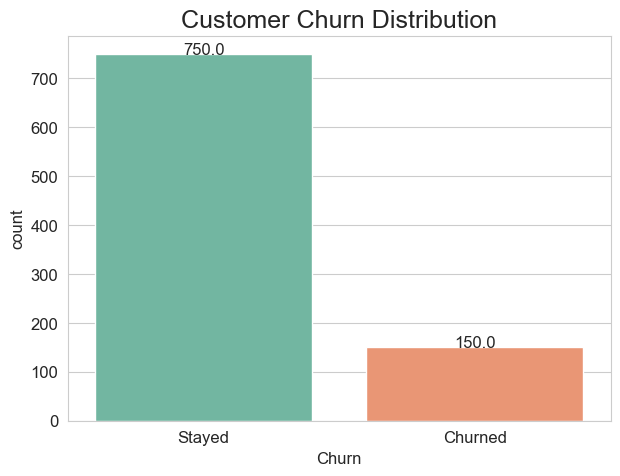

In [6]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='Churn',
    data=df,
    palette='Set2'
)

for p in ax.patches:
    
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        fontsize=12
    )

plt.xticks(
    [0,1],
    ['Stayed', 'Churned']
)

plt.title("Customer Churn Distribution", fontsize=18)

plt.show()

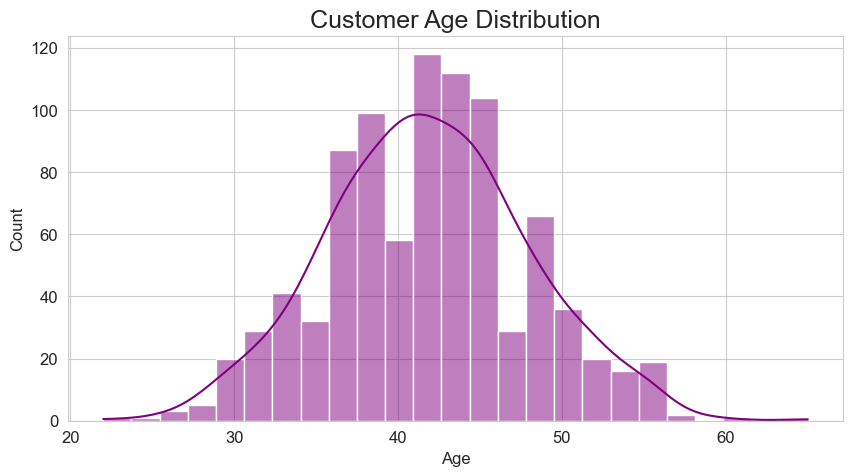

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Age'],
    bins=25,
    kde=True,
    color='purple'
)

plt.title("Customer Age Distribution", fontsize=18)

plt.show()

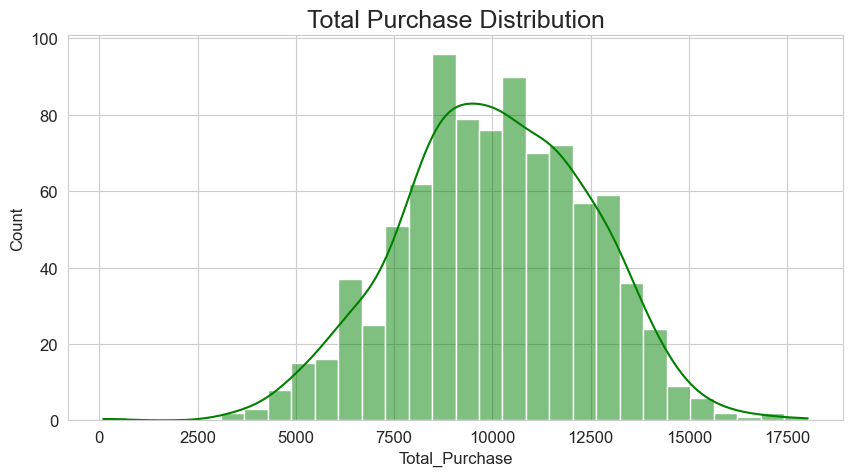

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Total_Purchase'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Total Purchase Distribution", fontsize=18)

plt.show()

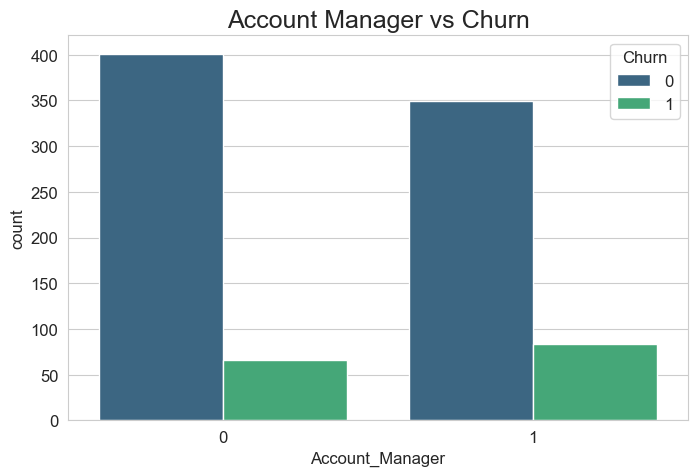

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Account_Manager',
    hue='Churn',
    data=df,
    palette='viridis'
)

plt.title("Account Manager vs Churn", fontsize=18)

plt.show()

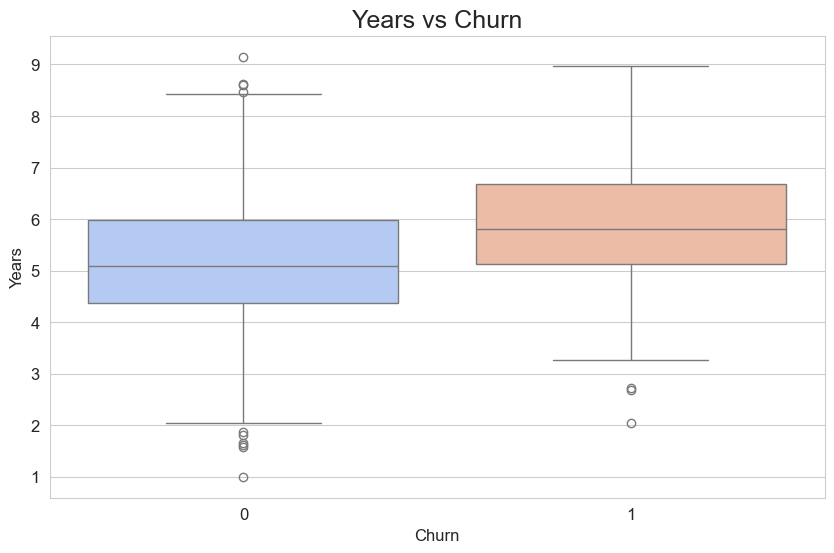

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Churn',
    y='Years',
    data=df,
    palette='coolwarm'
)

plt.title("Years vs Churn", fontsize=18)

plt.show()


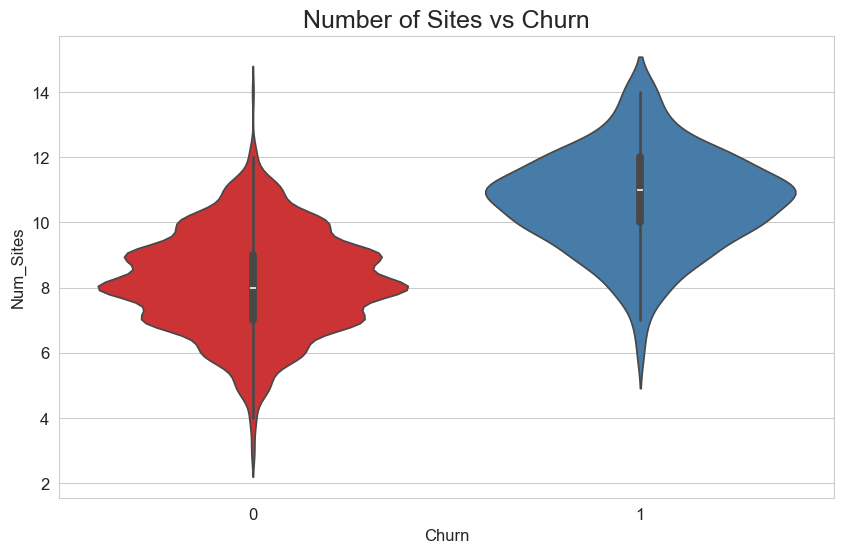

In [11]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='Churn',
    y='Num_Sites',
    data=df,
    palette='Set1'
)

plt.title("Number of Sites vs Churn", fontsize=18)

plt.show()

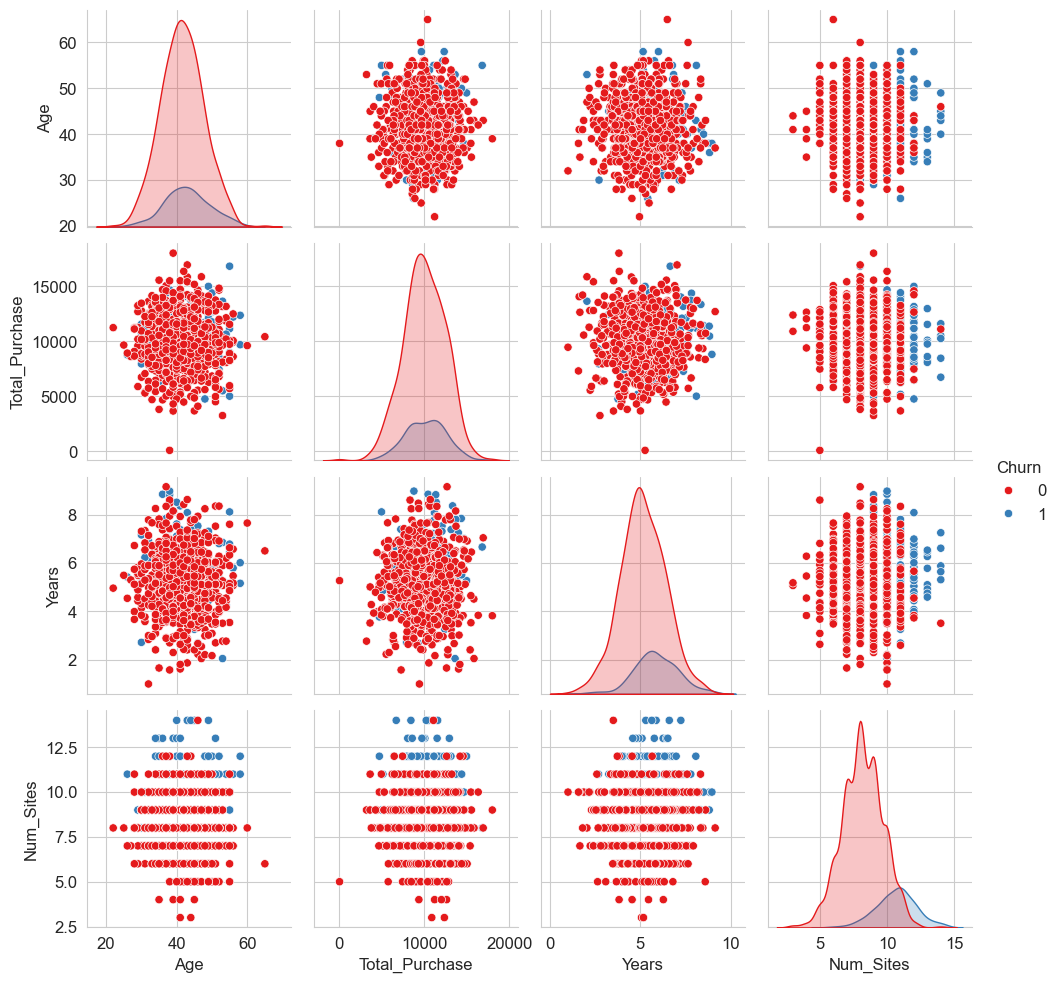

In [12]:
sns.pairplot(
    df[
        [
            'Age',
            'Total_Purchase',
            'Years',
            'Num_Sites',
            'Churn'
        ]
    ],
    hue='Churn',
    palette='Set1'
)

plt.show()

In [13]:
df.drop(
    ['Names', 'Onboard_date', 'Location', 'Company'],
    axis=1,
    inplace=True
)

df.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42.0,11066.80,0,7.22,8.0,1
1,41.0,11916.22,0,6.50,11.0,1
2,38.0,12884.75,0,6.67,12.0,1
3,42.0,8010.76,0,6.71,10.0,1
4,37.0,9191.58,0,5.56,9.0,1


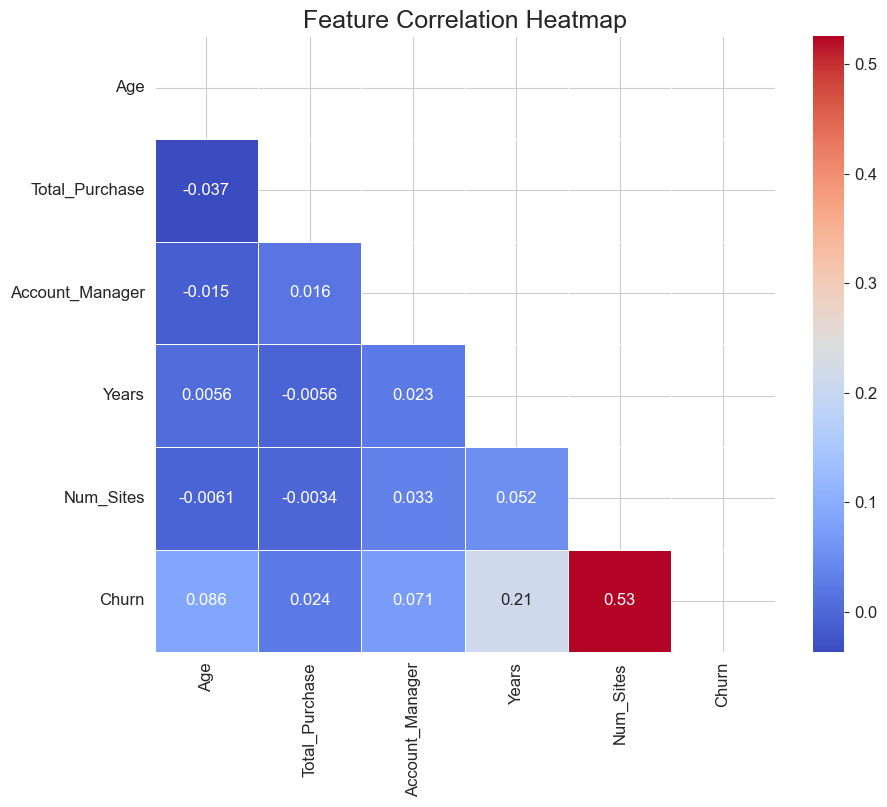

In [14]:
plt.figure(figsize=(10,8))

corr = df.corr()

mask = np.triu(np.ones_like(corr))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=18)

plt.show()

In [15]:
X = df.drop('Churn', axis=1)

y = df['Churn']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [19]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.9055555555555556


In [20]:

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.8722222222222222


In [21]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", dt_accuracy)


Decision Tree Accuracy : 0.8666666666666667


In [22]:
knn_model = KNeighborsClassifier(
    n_neighbors=7
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.8722222222222222


In [23]:
svm_model = SVC(
    probability=True
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy :", svm_accuracy)

SVM Accuracy : 0.8777777777777778


In [24]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy :", gb_accuracy)

Gradient Boosting Accuracy : 0.8888888888888888


In [25]:
models = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Decision Tree',
        'KNN',
        'SVM',
        'Gradient Boosting'
    ],

    'Accuracy': [
        lr_accuracy,
        rf_accuracy,
        dt_accuracy,
        knn_accuracy,
        svm_accuracy,
        gb_accuracy
    ]
})

models

,Model,Accuracy
0,Logistic Regression,0.905556
1,Random Forest,0.872222
2,Decision Tree,0.866667
3,KNN,0.872222
4,SVM,0.877778
5,Gradient Boosting,0.888889


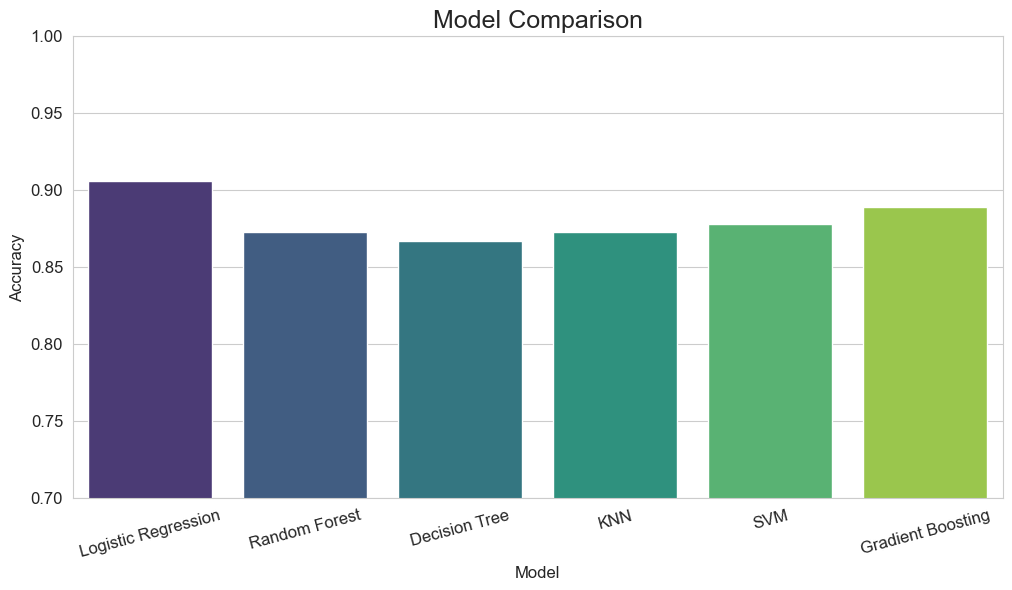

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=models,
    palette='viridis'
)

plt.title("Model Comparison", fontsize=18)

plt.ylim(0.7,1.0)

plt.xticks(rotation=15)

plt.show()

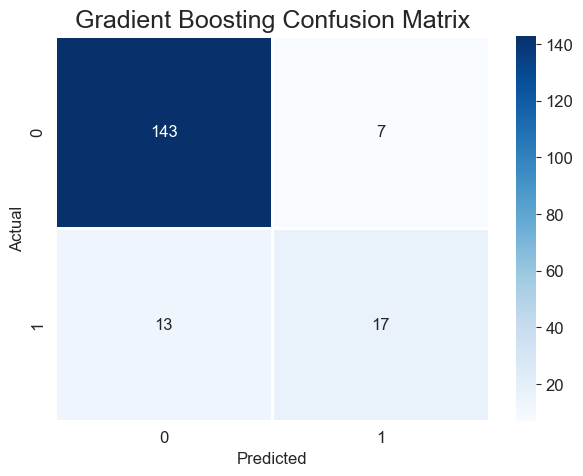

In [27]:
plt.figure(figsize=(7,5))

sns.heatmap(
    confusion_matrix(y_test, gb_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1
)

plt.title("Gradient Boosting Confusion Matrix", fontsize=18)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       150
           1       0.71      0.57      0.63        30

    accuracy                           0.89       180
   macro avg       0.81      0.76      0.78       180
weighted avg       0.88      0.89      0.88       180



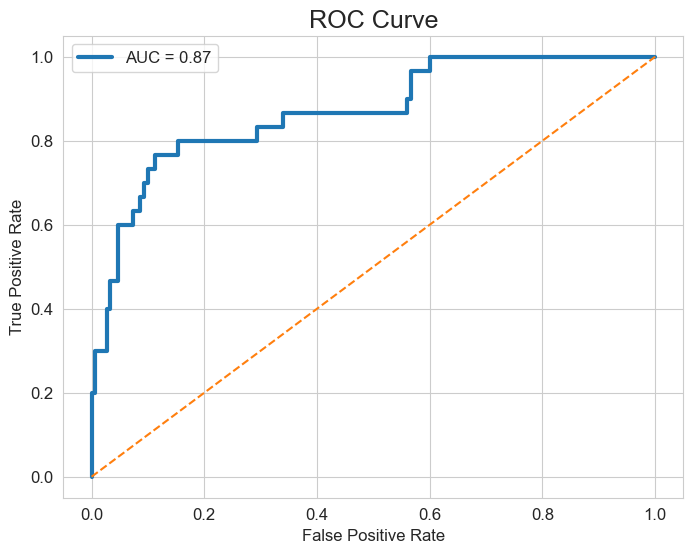

In [29]:
gb_probs = gb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    gb_probs
)

auc_score = roc_auc_score(
    y_test,
    gb_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'AUC = {auc_score:.2f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve", fontsize=18)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [30]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': gb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,Num_Sites,0.527465
3,Years,0.264376
1,Total_Purchase,0.097800
0,Age,0.079685
2,Account_Manager,0.030673


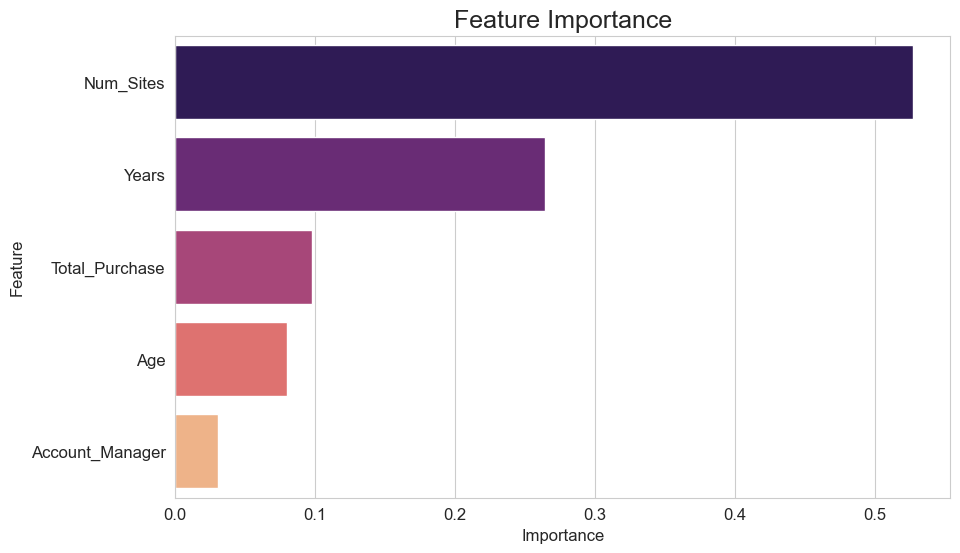

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    palette='magma'
)

plt.title("Feature Importance", fontsize=18)

plt.show()